In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

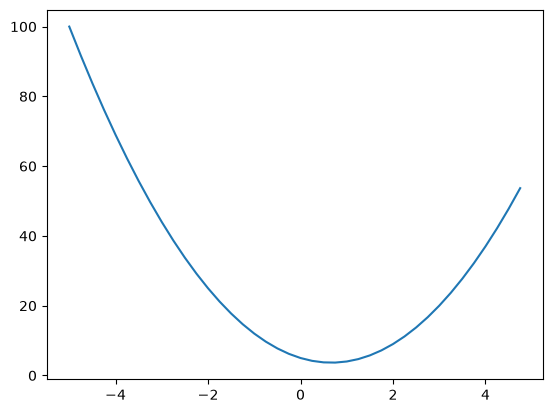

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [12]:
h = 0.000001
x = 2.0/3.0
(f(x + h) - f(x)) / h

2.999378523327323e-06

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

print(d)

4.0


In [ ]:
h = 0.001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2 - d1) / h)

d1 4.0
d2 3.997
slop -3.0000000000001137


In [16]:
h = 0.001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2 - d1) / h)

d1 4.0
d2 4.002
slop 1.9999999999997797


In [ ]:
h = 0.001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2 - d1) / h)

d1 4.0
d2 4.0009999999999994
slop 0.9999999999994458


In [145]:
class Value:
    def __init__(self, data, children=(), op='', label=''):
        self._data = data
        self._grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self._op = op
        self._label = label

    def __repr__(self):
        return f"Value(data={self._data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self._data + other._data, (self, other), '+')
        def backward():
            self._grad += 1.0 * out._grad
            other._grad += 1.0 * out._grad
        out._backward = backward
        return out

    def __radd__(self, other):
        return self + other
    
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self._data * other._data, (self, other), '*')
        def backward():
            self._grad += other._data * out._grad
            other._grad += self._data * out._grad
        out._backward = backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)
    
    def __pow__(self, other):
        out = Value(self._data ** other, (self, ), label=f"**{other}")

        def backward():
            self._grad += other * (self._data ** (other - 1)) * out._grad
        out._backward = backward
        return out
    

    def exp(self):
        out = Value(math.exp(self._data), (self, ), 'exp')
        def backward():
            self._grad = out._data * out._grad
        out._backward = backward
        return out

    def tanh(self):
        t = math.tanh(self._data)
        out = Value(t, (self, ), label='tanh')
        def backward():
            self._grad += (1.0 - t ** 2) * out._grad
        out._backward = backward
        return out
    
    def backward(self):
        self._grad = 1.0
        topo =[]
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                    topo.append(v)
        build_topo(self)
        for node in reversed(topo):
            node._backward()
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e._label = 'e'
d = e + c; d._label = 'd'

f = Value(-2.0, label='f')
L = d * f; L._label = 'L'
L

Value(data=-8.0)

In [67]:
a = Value(2.0, label='a')
2*a

Value(data=4.0)

In [47]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR= left to right
    nodes,edges = trace(root)
    for n in nodes:
        uid =str(id(n))# for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label= "{ %s | data %.4f | grad %.4f }" %(n._label, n._data, n._grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)#and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1,n2 in edges:  #connect nl to the op node of n2
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    return dot

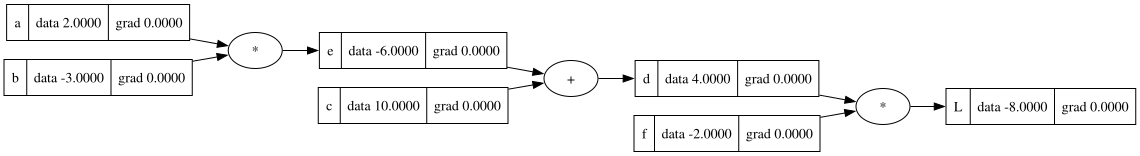

In [48]:
draw_dot(L)

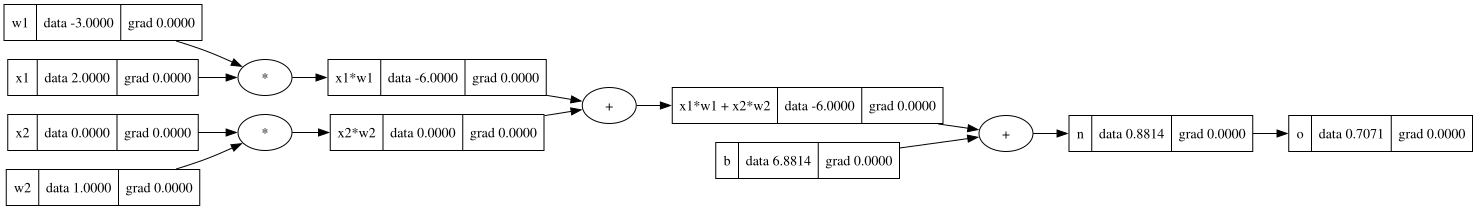

In [60]:
# inputs xl,x2
x1= Value(2.0,label='x1')
x2=Value(0.0,label='x2')

# weights wl,w2
w1=Value(-3.0,label='w1')
w2 =Value(1.0,label='w2')

# bias of the neuron
b=Value(6.8813735870195432, label='b')
#xI*wl +x2*w2 + b
x1w1 =x1*w1; x1w1._label='x1*w1'
x2w2=x2*w2; x2w2._label='x2*w2'

x1w1x2w2=x1w1+x2w2;x1w1x2w2._label='x1*w1 + x2*w2'
n=x1w1x2w2+b;n._label='n'

o=n.tanh();o._label='o'

draw_dot(o)

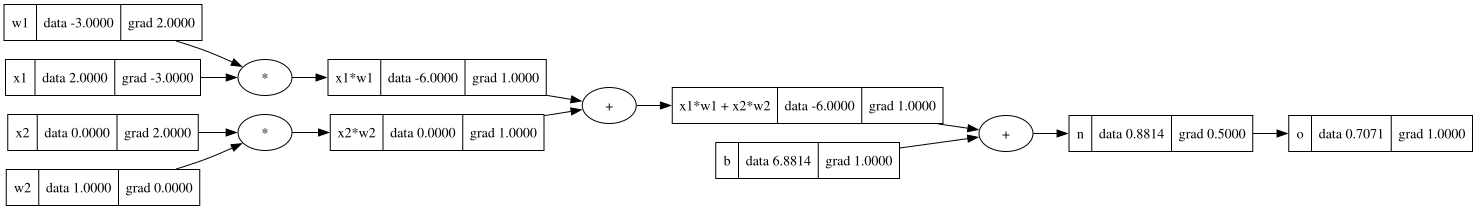

In [ ]:
o.backward()
draw_dot(o)

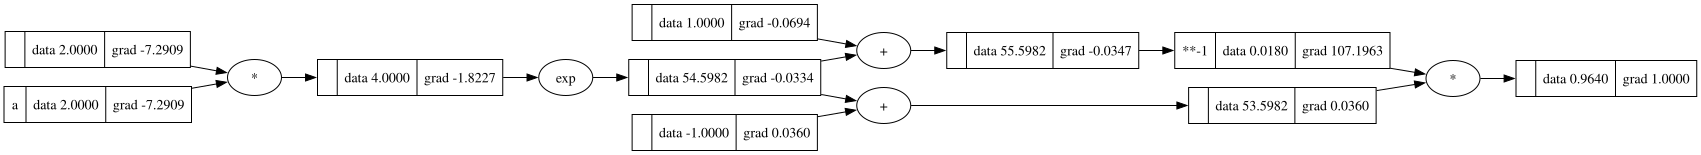

In [ ]:
a = Value(2.0, label='a')
b = (2 * a).exp()
c = (b -1) / (b + 1)
c.backward()
draw_dot(c)

In [74]:
import torch

x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

b = torch.Tensor([6.8813]).double()
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())

print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7070699720278941
----
x2 0.5000520546564731
w2 0.0
x1 -1.5001561639694192
w1 1.0001041093129461


In [166]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')


    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    

class Layer:
    def __init__(self, nin, nout):
        self._neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self._neurons]

        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for neuron in self._neurons for p in neuron.parameters()]
    

class MLP:
    def __init__(self, nin, nout):
        sz = [nin] + nout
        self._layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))]

    def __call__(self, x):
        for layer in self._layers:
            x = layer(x)

        return x
    
    def parameters(self):
        return [p for layer in self._layers for p in layer.parameters()]

x = [2.0, 3.0, -1]

n = MLP(3, [4, 4, 1])
n(x)

# draw_dot(n(x))


Value(data=0.32467993964933156)

In [202]:
xs = [
    [2.0, 3.0, -1],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [204]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
    loss = sum(loss)

    for p in n.parameters():
        p._grad = 0.0
    loss.backward()

    for p in n.parameters():
        p._data += -0.001 * p._grad

    print(k, loss._data, ypred)

0 0.0112305419838494 [Value(data=0.9841966900797863), Value(data=-0.948536776297694), Value(data=-0.9099890952721192), Value(data=0.984822022017085)]
1 0.011111948393291758 [Value(data=0.9842157510324713), Value(data=-0.9486573870367576), Value(data=-0.9105744033180763), Value(data=0.9848406916380914)]
2 0.01095773239442932 [Value(data=0.9842319496041528), Value(data=-0.9488413790946554), Value(data=-0.9113286619791094), Value(data=0.9848576652463515)]
3 0.010693728710679041 [Value(data=0.9842697360501096), Value(data=-0.9492557609104748), Value(data=-0.9125746306248667), Value(data=0.9848965402773927)]
4 0.01054039531494549 [Value(data=0.9842731225673114), Value(data=-0.9495558149213856), Value(data=-0.9132792279480093), Value(data=0.9849019031787497)]
5 0.010475232285517014 [Value(data=0.9842911912524309), Value(data=-0.9496635425082465), Value(data=-0.9135864329020612), Value(data=0.9849201431757383)]
6 0.010370038755575416 [Value(data=0.9843064457786705), Value(data=-0.949786057041